Inputs shape: (38, 6)
Outputs shape: (38,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source
32     0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182  week-3
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file
30     0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423  week-1
37     0.067812     0.504863     0.287394     0.230127     0.473182     0.728104  1.124186  week-8
31     0.060606     0.484848     0.242424     0.181818     0.484848     0.727273  0.976917  week-2
36     0.056006     0.252690     0.914472     0.121294     0.362425     1.007224  0.916195  week-7
24     0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142    file
14     0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526    file
0      0.272624     0.324495     0.8971

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


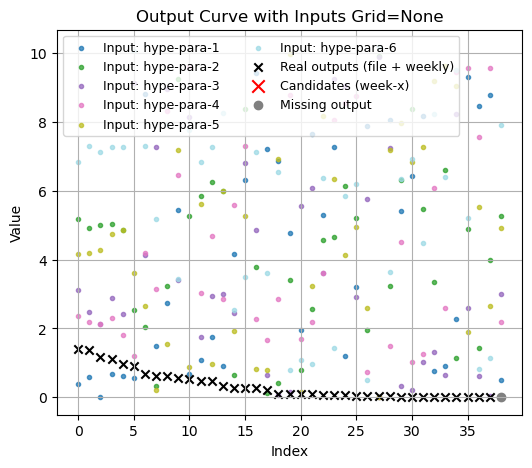

Saved LLM candidates to: results/run_2025-12-22 12-02-07/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))